In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import exp
import numpy as np


In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [3]:
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 150


In [3]:
df= pd.read_csv('..\\SampleData\\SampleData\\Insurance.csv')

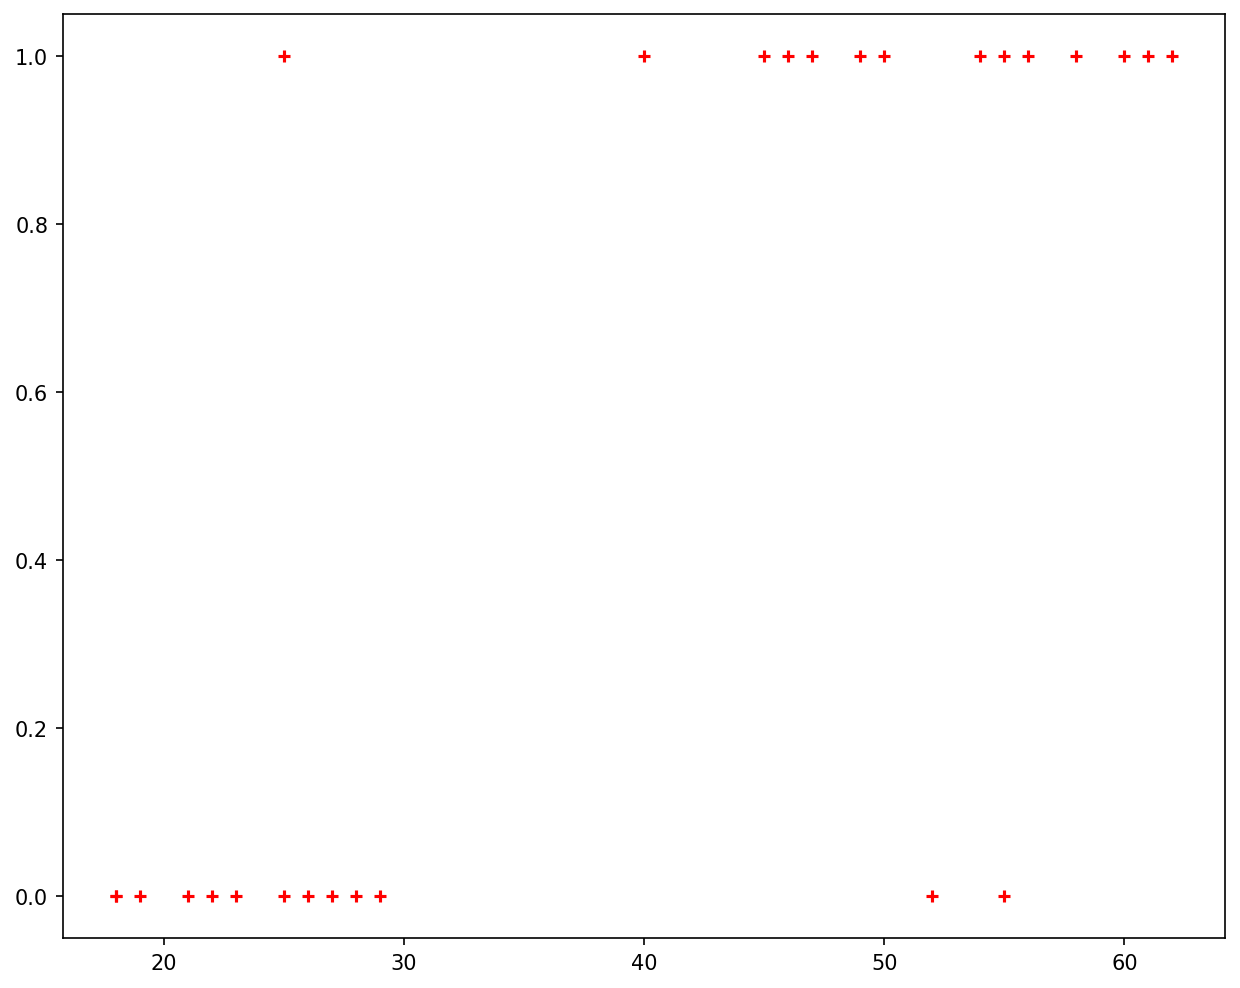

In [5]:
plt.scatter(df.age,df['bought_insurance'],
            color='red',marker='+')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df[['age']],df['bought_insurance'],
                                                   test_size=0.1)

In [7]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X_train,y_train)

In [8]:
intercept = model.intercept_
coefs = model.coef_
score = model.score(X_train,y_train)
prob_matrix = model.predict_proba(X_train)

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_train)
print(classification_report(y_train,y_pred))
cm = confusion_matrix(y_train,y_pred)


              precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       0.86      0.92      0.89        13

    accuracy                           0.88        24
   macro avg       0.88      0.87      0.87        24
weighted avg       0.88      0.88      0.87        24



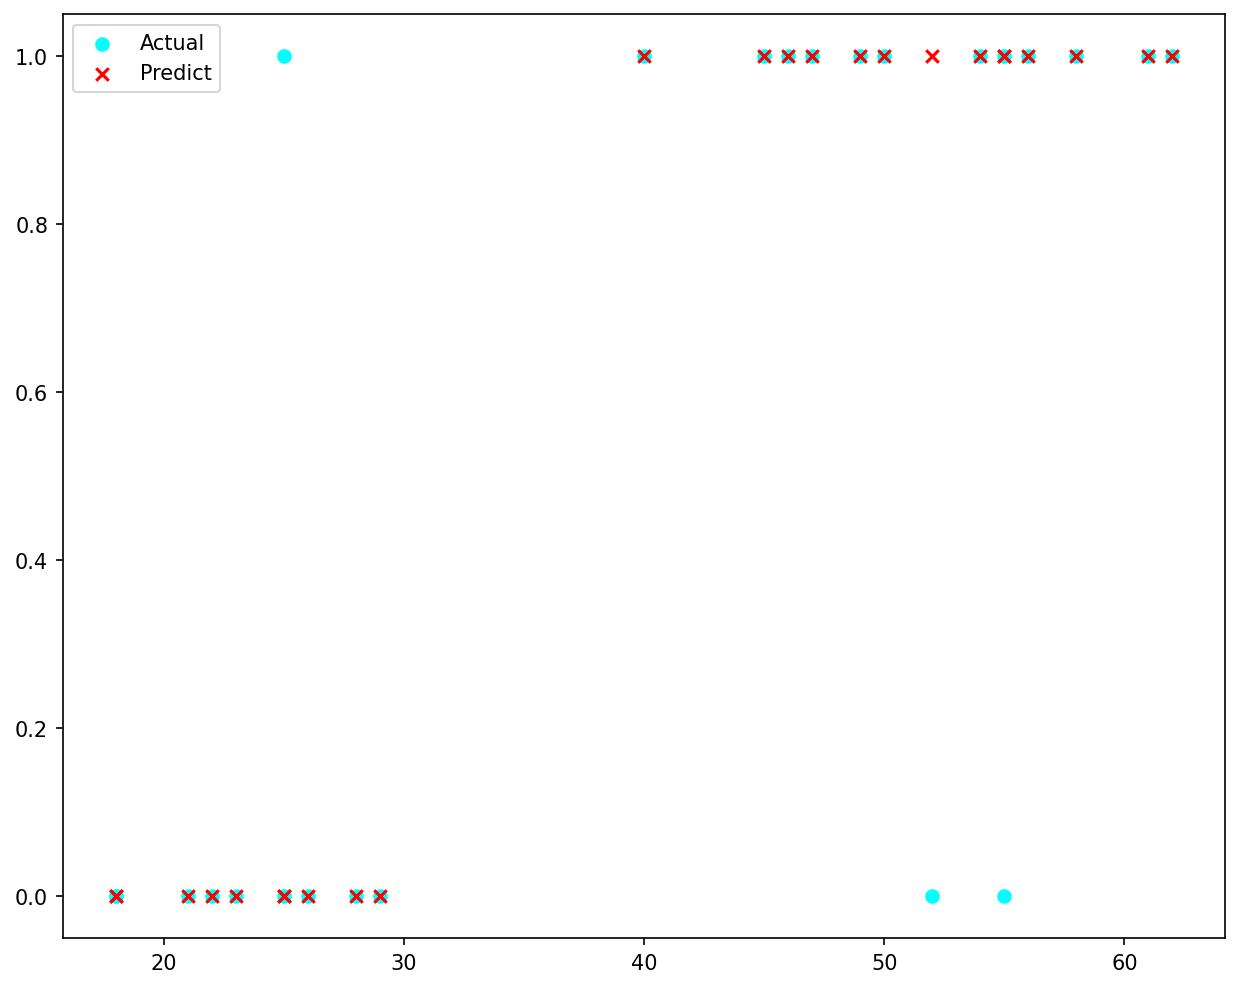

In [10]:
plt.scatter(X_train,y_train,color='cyan',marker='o',label='Actual')
plt.scatter(X_train,y_pred,color='red',marker='x',label='Predict')

plt.legend()
plt.show()

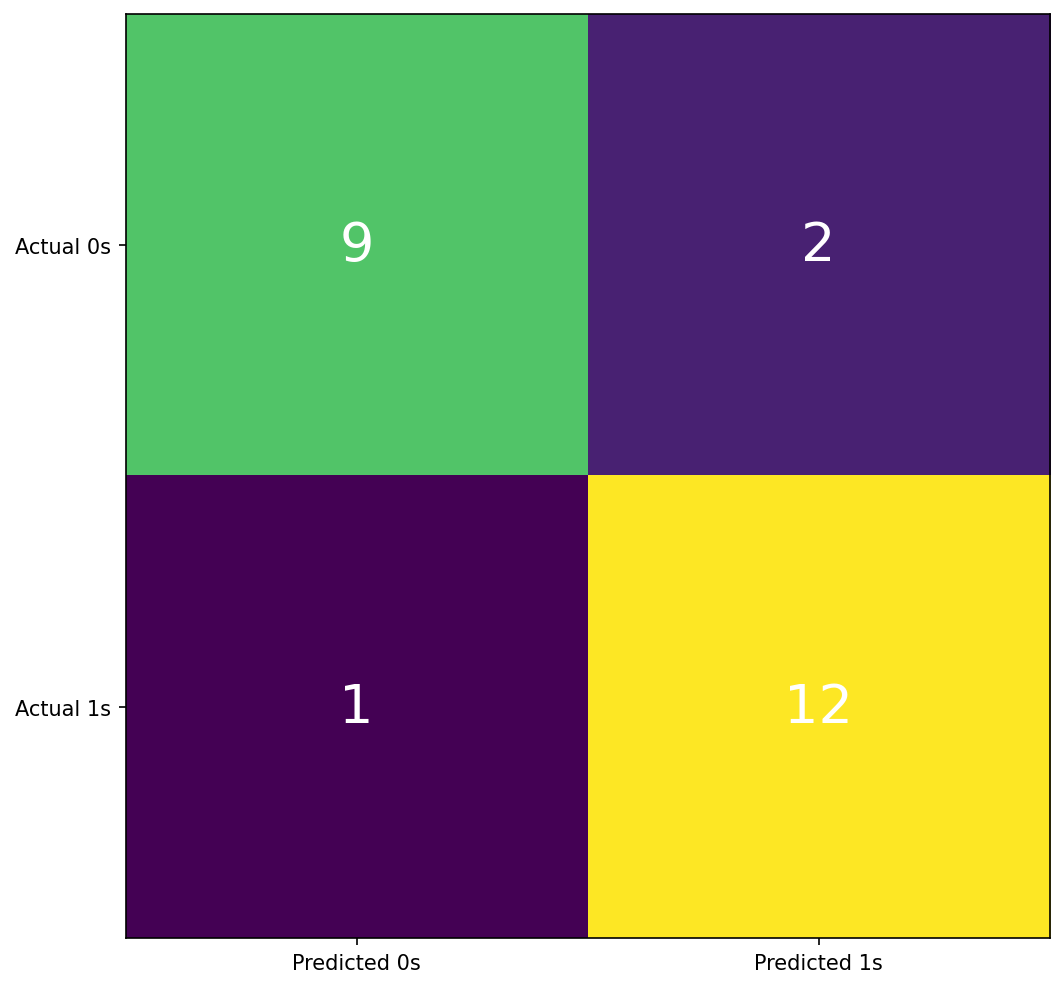

In [11]:
fig,ax = plt.subplots()
ax.imshow(cm)
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white',fontsize=26)
plt.show()



In [12]:
pred_values = model.predict_proba(X_test)
pred_score = model.score(X_test,y_test)
pred_prob_matrix = model.predict_proba(X_test)

In [13]:
def prediction_func(age,inter,coef):
    x= inter + coef*age
    return sigmoid(x)

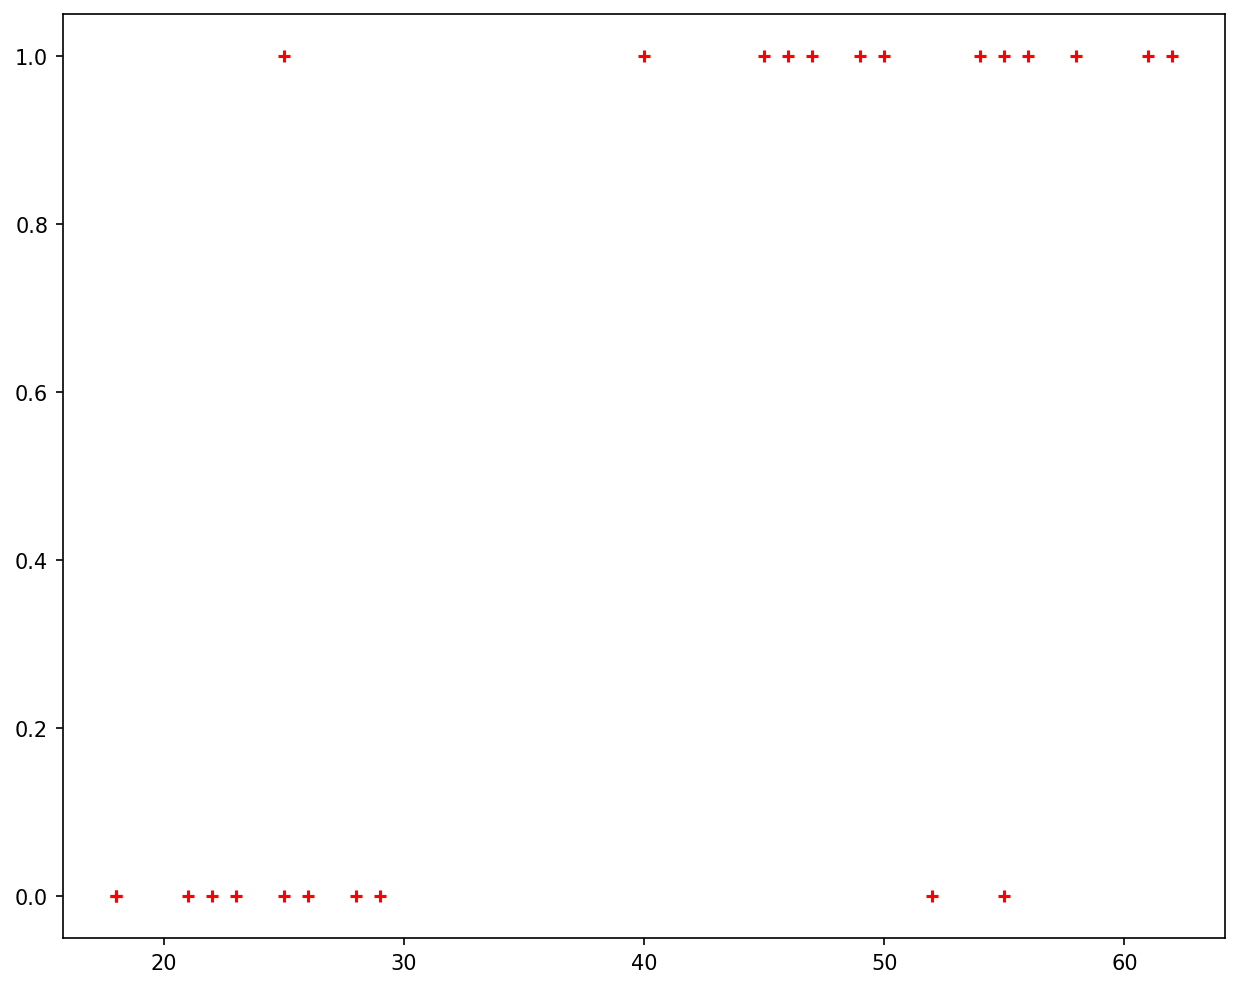

In [14]:
plt.scatter(X_train,y_train,color='red',marker='+')
x_test= np.linspace